In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

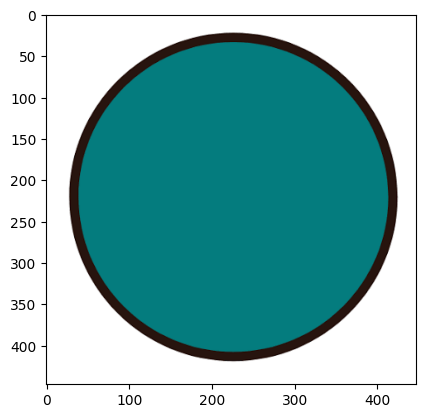

In [37]:
circle = cv2.imread("circle.png")
plt.imshow(circle[:, :, ::-1])

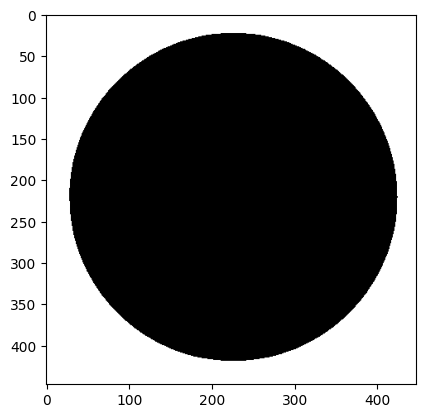

In [39]:
circle_gray = cv2.cvtColor(circle, cv2.COLOR_BGR2GRAY)
_, circle_bin = cv2.threshold(circle_gray, 100, 255, cv2.THRESH_BINARY)
plt.imshow(circle_bin, cmap = 'gray')

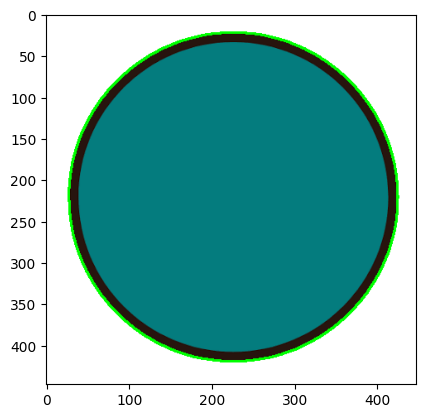

In [43]:
contours, hierarchy = cv2.findContours(circle_bin, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

w, h = circle.shape[:2]
img_area = w*h

valid_contours = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    if  area < (0.98 * img_area):
        valid_contours.append(cnt)


cv2.drawContours(circle, valid_contours, 0, (0, 255, 0), 2)
plt.imshow(circle[:, :, ::-1])

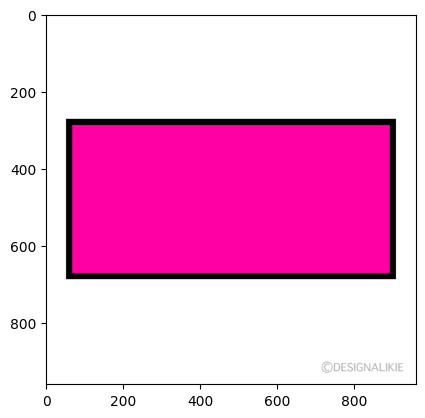

In [111]:
rect = cv2.imread("rectangle.png")
plt.imshow(rect[:, :, ::-1])

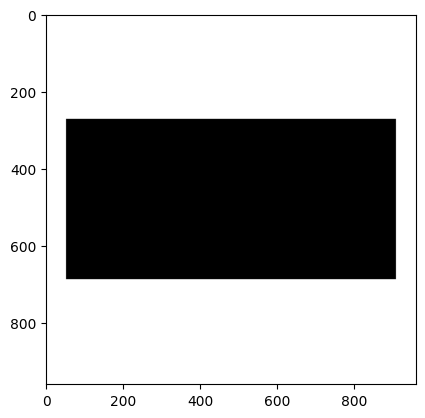

In [52]:
rect_gray = cv2.cvtColor(rect, cv2.COLOR_BGR2GRAY)
_, rect_bin = cv2.threshold(rect_gray, 100, 255, cv2.THRESH_BINARY)
plt.imshow(rect_bin, cmap = 'gray')

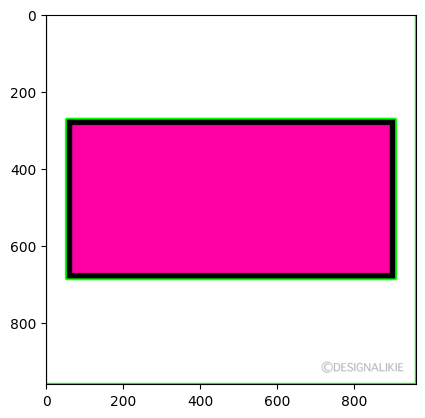

In [58]:
contours, hierarchy = cv2.findContours(rect_bin, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

cv2.drawContours(rect, contours, -1, (0, 255, 0), 3)
plt.imshow(rect[:, :, ::-1])

## Shape Detection

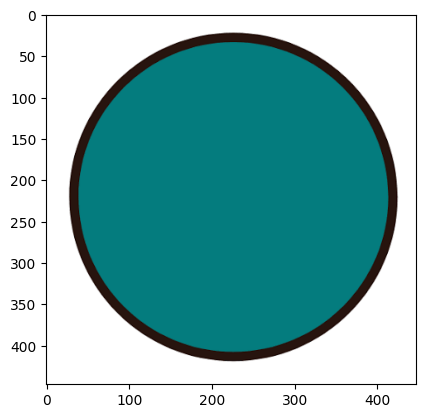

In [83]:
circle = cv2.imread("circle.png")
plt.imshow(circle[:, :, ::-1])

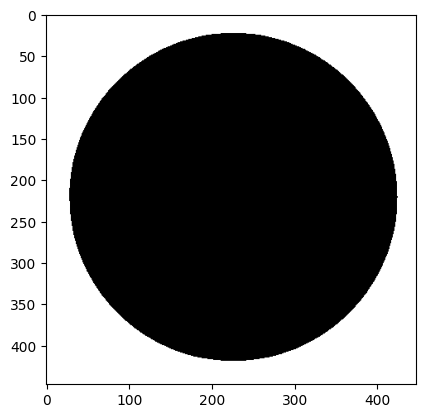

In [48]:
circle_gray = cv2.cvtColor(circle, cv2.COLOR_BGR2GRAY)
_, circle_bin = cv2.threshold(circle_gray, 100, 255, cv2.THRESH_BINARY)
plt.imshow(circle_bin, cmap = 'gray')

In [164]:
shapes = {
    3 : 'Triangle',
    4 : 'Rectangle',
    5 : 'Pentagon',
    6 : 'Hexagon', 
    7 : 'Heptagon', 
    8 : 'Octagon'
}

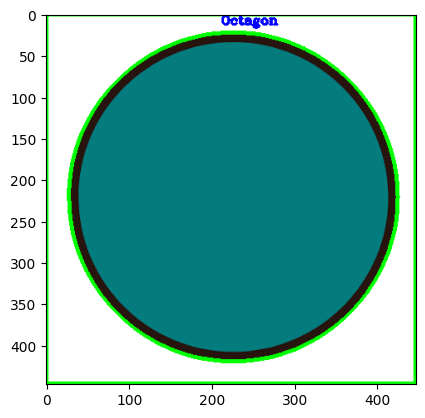

In [73]:
contours, hierarchy = cv2.findContours(circle_bin, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

cv2.drawContours(circle, contours, -1, (0, 255, 0), 3)

for cnt in contours:
    perimeter = cv2.arcLength(cnt, True)

    epsilon = 0.02 * perimeter
    approx = cv2.approxPolyDP(cnt, epsilon, True)

    vertices = len(approx)

    shape = shapes.get(vertices, 'Circle')

    x = approx.ravel()[0]
    y = approx.ravel()[1] - 10
    cv2.putText(circle, f"{shape}", (x, y), cv2.FONT_HERSHEY_COMPLEX, 0.5, (255, 0, 0), 2)

plt.imshow(circle[:, : ,::-1])

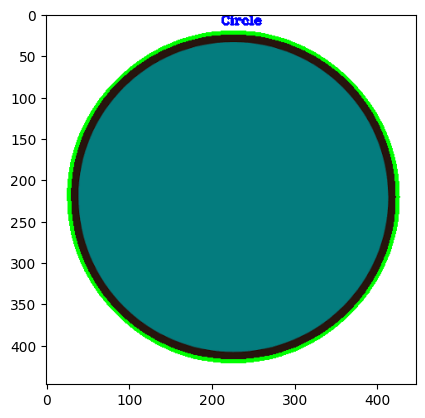

In [119]:
contours, hierarchy = cv2.findContours(circle_bin, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

w, h = circle.shape[:2]
total_area = w*h

for cnt in contours:
    perimeter = cv2.arcLength(cnt, True)

    epsilon = 0.01 * perimeter #Changed the epsilon to 0.01
    approx = cv2.approxPolyDP(cnt, epsilon, True)

    vertices = len(approx)

    shape = shapes.get(vertices, 'Circle')

    area = cv2.contourArea(cnt)
    if area < (0.98 * total_area):
        cv2.drawContours(circle, [cnt], -1, (0, 255, 0), 3)

    x = approx.ravel()[0]
    y = approx.ravel()[1] - 10
    cv2.putText(circle, f"{shape}", (x, y), cv2.FONT_HERSHEY_COMPLEX, 0.5, (255, 0, 0), 2)

plt.imshow(circle[:, : ,::-1])

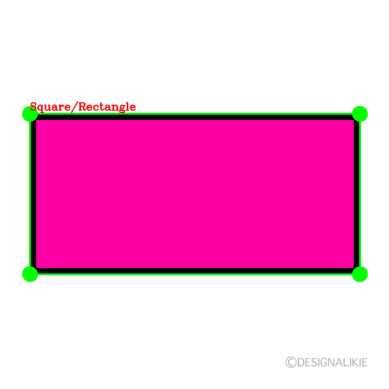

In [125]:
# For rectangle
contours, hierarchy = cv2.findContours(rect_bin, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

#print(hierarchy)
h, w = rect.shape[:2]  # shape[:2] gives (height, width)
total_area = w * h

for cnt in contours:
    area = cv2.contourArea(cnt)
    
    # Filter out the full-canvas outer border
    if area < (0.98 * total_area) and area > 100:  # Also filters small noise
        # FIX 1: Wrap 'cnt' inside a list '[cnt]'
        cv2.drawContours(rect, [cnt], -1, (0, 255, 0), 4)

        perimeter = cv2.arcLength(cnt, True)
        epsilon = 0.01 * perimeter
        approx = cv2.approxPolyDP(cnt, epsilon, True)

        shape = shapes.get(len(approx), "Circle")

        x = approx.ravel()[0]
        y = approx.ravel()[1] - 10
        
        # FIX 2: Move text rendering inside the if block
        cv2.putText(rect, f"{shape}", (x, y), cv2.FONT_HERSHEY_COMPLEX, 0.9, (0, 0, 255), 2)

plt.imshow(rect[:, :, ::-1])
plt.axis('off')
plt.show()

## Mini fun experiment

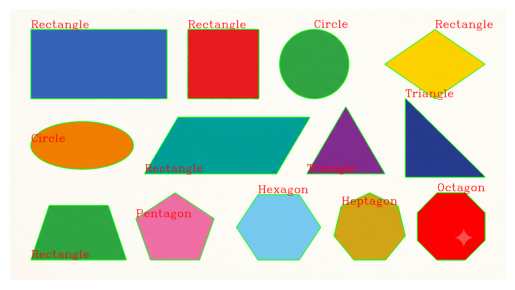

In [184]:
shapes_img = cv2.imread("shapes.png")

shapes_gray = cv2.cvtColor(shapes_img, cv2.COLOR_BGR2GRAY)
_, shapes_thresh = cv2.threshold(shapes_gray, 240, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(shapes_thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

h, w = shapes_img.shape[:2]
img_area = w*h

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < (0.98 * img_area) and area > 100:
        cv2.drawContours(shapes_img, [cnt], -1, (0, 255, 0), 4)

        perimeter = cv2.arcLength(cnt, True)
        epsilon = 0.01 * perimeter
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        approx1D = approx.ravel()
        x = approx1D[0]
        y = approx1D[1] - 10
        shape = shapes.get(len(approx), "Circle")
        
        cv2.putText(shapes_img, f"{shape}", (x, y), cv2.FONT_HERSHEY_COMPLEX, 2, (0, 0, 255), 2)

plt.imshow(shapes_img[:, :, ::-1])
plt.axis('off')
plt.show()

Total shapes detected: 14


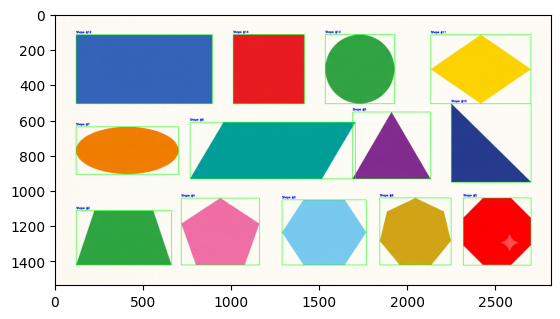

In [148]:
import cv2

# 1. Load image containing multiple shapes
img = cv2.imread('shapes.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Invert threshold (shapes become white=255, background becomes black=0)
_, thresh = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)

# 3. Find ALL distinct contours in the image
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f"Total shapes detected: {len(contours)}")

# 4. Loop through each detected shape individually
for i, cnt in enumerate(contours):
    # Filter out small noise artifacts
    if cv2.contourArea(cnt) > 100:
        # Draw bounding box around THIS specific shape
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        
        # Label each shape with its index number
        cv2.putText(img, f"Shape #{i+1}", (x, y - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

plt.imshow(img[:, :, ::-1])